# SCNN Lane Detection — End-to-End Pipeline

Walks the whole repository pipeline in order, using the repo's own modules
(`dataset/`, `model.py`, `utils/transforms/`, `utils/prob2lines/`) rather than
re-implementing them:

| Section | Mirrors | Produces |
|---|---|---|
| 2. Data | `dataset/CULane.py` | sample grid |
| 3. Model | `model.py` | untrained probability maps |
| 4. Training | `train.py` | loss / LR curves |
| 5. Checkpoint | `train.py` save block | `<exp>.pth`, `<exp>_best.pth` |
| 6. Validation | `train.py:val()` | predicted vs ground-truth overlays |
| 7. Testing | `test_CULane.py` | `coord_output/*.lines.txt`, lane plots |
| 8. Demo | `demo_test.py` | single-image overlay |
| 9. Evaluation | `utils/lane_evaluation/` | per-lane IoU |

**Data.** If `config.Dataset_Path['CULane']` points at a real CULane copy the
notebook uses it. Otherwise it writes a small **toy dataset in CULane's exact
on-disk format** (images + `laneseg` label PNGs + `list/*_gt.txt`) so every
downstream cell exercises the real code path. Numbers from a toy run are for
plumbing verification only — they are not model results.

**Logging.** `utils/tensorboard.py` imports `tensorflow` and `scipy.misc` and does
not run on a modern stack; this notebook plots inline with matplotlib instead.

## 0. Environment

In [1]:
import os, sys, json, time, shutil, warnings
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore", category=UserWarning)  # torchvision `pretrained=` shim

In [2]:
REPO = Path.cwd()
assert (REPO / "model.py").exists(), f"run this notebook from the repo root, not {REPO}"
sys.path.insert(0, str(REPO))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

In [3]:
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.13.0 | device: mps


## 1. Experiment configuration

Every entry point in this repo is driven by `--exp_dir`: a directory holding a
`cfg.json`, into which checkpoints, `coord_output/` and `evaluate/` are written.
The directory's basename doubles as the checkpoint filename. We create a
dedicated one so `exp0` / `exp10` stay untouched.

In [4]:
EXP_DIR  = REPO / "experiments" / "exp_notebook"
EXP_NAME = EXP_DIR.name
EXP_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
cfg = {
    "device": str(device),
    "dataset":      {"dataset_name": "CULane", "batch_size": 4, "resize_shape": [512, 288]},
    "optim":        {"lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4, "nesterov": True},
    "lr_scheduler": {"warmup": 5, "max_iter": 60, "min_lrs": 1e-10},
}
(EXP_DIR / "cfg.json").write_text(json.dumps(cfg, indent=2))
print((EXP_DIR / "cfg.json").read_text())

{
  "device": "mps",
  "dataset": {
    "dataset_name": "CULane",
    "batch_size": 4,
    "resize_shape": [
      512,
      288
    ]
  },
  "optim": {
    "lr": 0.01,
    "momentum": 0.9,
    "weight_decay": 0.0001,
    "nesterov": true
  },
  "lr_scheduler": {
    "warmup": 5,
    "max_iter": 60,
    "min_lrs": 1e-10
  }
}


Re-read it the way `train.py` does. Note `train.py` calls
`exp_cfg['dataset'].pop('dataset_name')` — the config dict is mutated as a side
effect, and `optim` / `lr_scheduler` are splatted straight into `optim.SGD` and
`PolyLR`, so their keys must match those constructors.

In [6]:
with open(EXP_DIR / "cfg.json") as f:
    exp_cfg = json.load(f)

resize_shape = tuple(exp_cfg["dataset"]["resize_shape"])   # (W, H)
dataset_name = exp_cfg["dataset"].pop("dataset_name")
batch_size   = exp_cfg["dataset"]["batch_size"]
print(f"{dataset_name}  resize_shape={resize_shape}  batch_size={batch_size}")

CULane  resize_shape=(512, 288)  batch_size=4


## 2. Dataset

CULane's on-disk contract, as parsed by `dataset/CULane.py`:

```
list/train_gt.txt   /driver_x/clip/00000.jpg /laneseg_label_w16/.../00000.png 1 1 1 1
list/test.txt       /driver_x/clip/00000.jpg
```

Leading `/` is stripped (`l[0][1:]`) before `os.path.join`. The label PNG holds
lane ids `1..4` in channel 0 (`0` = background); the trailing four flags are the
per-lane existence targets for the BCE head.

In [7]:
from config import Dataset_Path

real_root = Path(Dataset_Path[dataset_name])
USE_TOY = not (real_root / "list").is_dir()
print(f"configured path : {real_root}\nusing toy data  : {USE_TOY}")

configured path : /home/lion/Dataset/CULane/data/CULane
using toy data  : True


### 2a. Toy data generator

Skipped entirely when a real CULane copy is present.

In [8]:
CU_H, CU_W = 590, 1640            # CULane native resolution
VP = (CU_W // 2, int(CU_H * .42))  # vanishing point

def _lane_pts(x_bottom, rng):
    """Four control points from the vanishing point down to `x_bottom`."""
    jitter = rng.uniform(-40, 40)
    return np.array([[VP[0] + jitter * .1, VP[1]],
                     [x_bottom + jitter * .6, CU_H - 1]], np.int32)

In [9]:
def draw_scene(rng):
    """One synthetic frame -> (BGR image, uint8 label with ids 1..4, exist flags)."""
    img = np.tile(np.linspace(90, 40, CU_H, dtype=np.uint8)[:, None, None], (1, CU_W, 3))
    img = np.ascontiguousarray(img)
    cv2.rectangle(img, (0, 0), (CU_W, VP[1]), (150, 160, 175), -1)   # sky
    label = np.zeros((CU_H, CU_W), np.uint8)

    exist, offsets = [], [-820, -280, 280, 820]
    for i, off in enumerate(offsets):
        present = rng.random() > .2
        exist.append(int(present))
        if not present:
            continue
        pts = _lane_pts(CU_W // 2 + off + rng.uniform(-60, 60), rng)
        cv2.polylines(img,   [pts], False, (235, 235, 235), 14, cv2.LINE_AA)
        cv2.polylines(label, [pts], False, int(i + 1), 16)
    img = np.clip(img.astype(np.float32) + rng.normal(0, 4, img.shape), 0, 255).astype(np.uint8)
    return img, label, exist

In [10]:
def build_toy_culane(root, counts=(24, 8, 8), seed=0):
    """Write a CULane-shaped tree: images, laneseg labels, and list files."""
    root = Path(root); rng = np.random.default_rng(seed)
    (root / "list").mkdir(parents=True, exist_ok=True)
    for split, n in zip(("train", "val", "test"), counts):
        rows = []
        for k in range(n):
            rel_img = f"driver_toy/{split}_clip/{k:05d}.jpg"
            rel_lbl = f"laneseg_label_w16/driver_toy/{split}_clip/{k:05d}.png"
            for rel in (rel_img, rel_lbl):
                (root / rel).parent.mkdir(parents=True, exist_ok=True)
            img, label, exist = draw_scene(rng)
            cv2.imwrite(str(root / rel_img), img)
            cv2.imwrite(str(root / rel_lbl), label)
            rows.append(f"/{rel_img} /{rel_lbl} " + " ".join(map(str, exist)))
        name = "test.txt" if split == "test" else f"{split}_gt.txt"
        body = [r.split(" ")[0] for r in rows] if split == "test" else rows
        (root / "list" / name).write_text("\n".join(body) + "\n")
    return root

In [11]:
if USE_TOY:
    data_root = build_toy_culane(REPO / "toy_data" / "CULane")
    print("toy tree written to", data_root)
else:
    data_root = real_root
print((data_root / "list" / "train_gt.txt").read_text().splitlines()[0])

toy tree written to /Users/harshwadhawe/Code/ICRA/SCNN_Pytorch/toy_data/CULane
/driver_toy/train_clip/00000.jpg /laneseg_label_w16/driver_toy/train_clip/00000.png 1 0 1 1


### 2b. Transforms and loaders

Every transform in `utils/transforms/` consumes and returns the sample dict
`{'img', 'segLabel', 'exist', 'img_name'}`; `Compose` chains them and each
`Dataset` supplies a static `collate` that tolerates the `test` split, where
`segLabel` and `exist` are `None`.

In [12]:
import dataset
from utils.transforms import Compose, Resize, Rotation, ToTensor, Normalize

mean, std = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)   # ImageNet, as in train.py
transform_train   = Compose(Resize(resize_shape), Rotation(2), ToTensor(), Normalize(mean, std))
transform_val_img = Resize(resize_shape)
transform_val     = Compose(transform_val_img, ToTensor(), Normalize(mean, std))

In [13]:
from torch.utils.data import DataLoader

Dataset_Type   = getattr(dataset, dataset_name)          # config-string -> class, as in train.py
train_dataset  = Dataset_Type(str(data_root), "train", transform_train)
val_dataset    = Dataset_Type(str(data_root), "val",   transform_val)
test_dataset   = Dataset_Type(str(data_root), "test",  transform_val)
print(f"train {len(train_dataset)} | val {len(val_dataset)} | test {len(test_dataset)}")

train 24 | val 8 | test 8


In [14]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          collate_fn=train_dataset.collate, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, collate_fn=val_dataset.collate,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, collate_fn=test_dataset.collate, num_workers=0)

sample = next(iter(train_loader))
print({k: (tuple(v.shape) if torch.is_tensor(v) else type(v).__name__) for k, v in sample.items()})

{'img': (4, 3, 288, 512), 'segLabel': (4, 288, 512), 'exist': (4, 4), 'img_name': 'list'}


### 2c. What the network sees

In [15]:
def denorm(t):
    """Normalized CHW tensor -> uint8 HWC RGB, for display."""
    a = t.cpu().numpy().transpose(1, 2, 0) * np.array(std) + np.array(mean)
    return (a.clip(0, 1) * 255).astype(np.uint8)

# model.py / demo_test.py list these as [[255,125,0],[0,255,0],[0,0,255],[0,255,255]], but
# those go to cv2.imwrite and are therefore BGR. Matplotlib draws RGB, so channel-swap them
# to reproduce demo/demo_result.jpg's actual colours.
LANE_COLORS = np.array([[255, 125, 0], [0, 255, 0], [0, 0, 255], [0, 255, 255]], np.uint8)[:, ::-1]

def overlay(rgb, mask, alpha=.8):
    lane = np.zeros_like(rgb)
    for i in range(4):
        lane[mask == i + 1] = LANE_COLORS[i]
    return cv2.addWeighted(lane, alpha, rgb, 1., 0.)

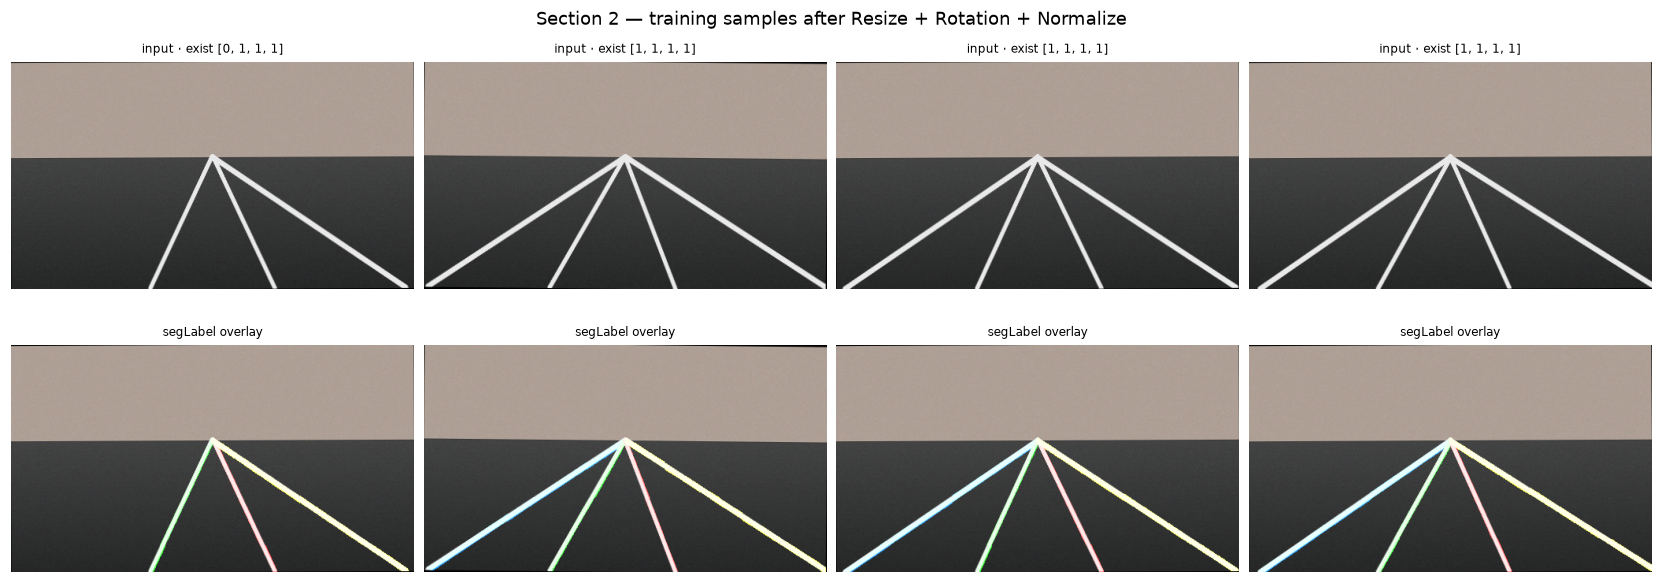

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(15, 5.4), layout="constrained")
for j in range(4):
    rgb = denorm(sample["img"][j])
    axes[0, j].imshow(rgb)
    axes[0, j].set_title(f"input · exist {sample['exist'][j].int().tolist()}", fontsize=8)
    axes[1, j].imshow(overlay(rgb, sample["segLabel"][j].numpy()))
    axes[1, j].set_title("segLabel overlay", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Section 2 — training samples after Resize + Rotation + Normalize")
plt.show()

## 3. Model

`SCNN.net_init` performs surgery on torchvision's `vgg16_bn.features`: modules
`34/37/40` are swapped for dilation-2 convolutions and the maxpools at `33`/`43`
are removed, giving a stride-8 feature map. Spatial message passing then slices
that map row-by-row and column-by-column in four directions, each slice
convolved and added to the next — the sequential loop that makes SCNN slow.

`forward()` returns `(seg_pred, exist_pred, loss_seg, loss_exist, loss)` and
computes the loss **inside** the module so `DataParallel` can shard it; that is
why `train.py` calls `.sum()` on the returned losses when wrapped.

In [17]:
from model import SCNN

net = SCNN(input_size=resize_shape, pretrained=True).to(device)
n_params = sum(p.numel() for p in net.parameters())
print(f"{n_params/1e6:.1f}M parameters | fc_input_feature = {net.fc_input_feature}")

20.5M parameters | fc_input_feature = 2880


In [18]:
print("message passing directions:", [n for n, _ in net.message_passing.named_children()])
print("loss weights: seg", net.scale_seg, "| exist", net.scale_exist,
      "| background", net.scale_background)

message passing directions: ['up_down', 'down_up', 'left_right', 'right_left']
loss weights: seg 1.0 | exist 0.1 | background 0.4


`fc_input_feature` is derived from `input_size`, so a checkpoint only loads back
at the `resize_shape` it was trained on.

In [19]:
net.eval()
with torch.no_grad():
    seg0, exist0 = net(sample["img"][:1].to(device))[:2]
    prob0 = torch.softmax(seg0, dim=1)[0].cpu().numpy()
print("seg_pred", tuple(seg0.shape), "| exist_pred", exist0.detach().cpu().numpy().round(2))

seg_pred (1, 5, 288, 512) | exist_pred [[0.51 0.49 0.5  0.48]]


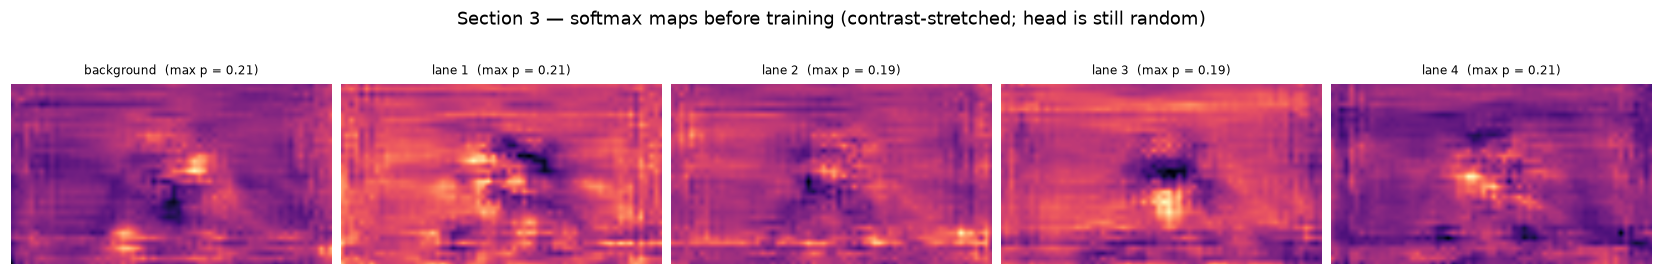

In [20]:
NAMES = ["background", "lane 1", "lane 2", "lane 3", "lane 4"]
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8), layout="constrained")
for i, ax in enumerate(axes):
    ax.imshow(prob0[i], cmap="magma")          # per-panel autoscale: absolute values are ~0.2 everywhere
    ax.set_title(f"{NAMES[i]}  (max p = {prob0[i].max():.2f})", fontsize=8)
    ax.axis("off")
fig.suptitle("Section 3 — softmax maps before training (contrast-stretched; head is still random)")
plt.show()

## 4. Training

Two details of `train.py` that are easy to miss:

- `MAX_EPOCHES` in `cfg.json` is **ignored** — `main()` overwrites it with
  `ceil(lr_scheduler.max_iter / len(train_loader))`. Training length is really
  controlled by `lr_scheduler.max_iter`.
- `PolyLR` is stepped **per batch**, so `max_iter` and `warmup` count
  iterations, not epochs.

In [21]:
import torch.optim as optim
from utils.lr_scheduler import PolyLR

optimizer    = optim.SGD(net.parameters(), **exp_cfg["optim"])
lr_scheduler = PolyLR(optimizer, 0.9, **exp_cfg["lr_scheduler"])

MAX_EPOCHES = int(np.ceil(exp_cfg["lr_scheduler"]["max_iter"] / len(train_loader)))
print(f"{len(train_loader)} iters/epoch -> MAX_EPOCHES = {MAX_EPOCHES}")

6 iters/epoch -> MAX_EPOCHES = 10


In [22]:
def train_one_epoch(epoch, history):
    net.train()
    for sample in train_loader:
        img     = sample["img"].to(device)
        segLabel= sample["segLabel"].to(device)
        exist   = sample["exist"].to(device)

        optimizer.zero_grad()
        _, _, loss_seg, loss_exist, loss = net(img, segLabel, exist)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()                       # per batch, not per epoch

        history["loss"].append(loss.item())
        history["seg"].append(loss_seg.item())
        history["exist"].append(loss_exist.item())
        history["lr"].append(optimizer.param_groups[0]["lr"])

In [23]:
@torch.no_grad()
def validate():
    net.eval()
    total = 0.
    for sample in val_loader:
        _, _, _, _, loss = net(sample["img"].to(device),
                               sample["segLabel"].to(device),
                               sample["exist"].to(device))
        total += loss.item()
    return total / max(len(val_loader), 1)

In [24]:
history = {k: [] for k in ("loss", "seg", "exist", "lr")}
val_curve, best_val_loss = [], 1e6

t0 = time.time()
for epoch in range(MAX_EPOCHES):
    train_one_epoch(epoch, history)
    v = validate()
    val_curve.append(v)
    best_val_loss = min(best_val_loss, v)
    print(f"epoch {epoch:2d} | train {history['loss'][-1]:.4f} | val {v:.4f}")
print(f"\n{time.time()-t0:.1f}s total, best val {best_val_loss:.4f}")

epoch  0 | train 0.3863 | val 1.0813


epoch  1 | train 0.3132 | val 0.5930


epoch  2 | train 0.2522 | val 0.4252


epoch  3 | train 0.1964 | val 0.3477


epoch  4 | train 0.1603 | val 0.2653


epoch  5 | train 0.1441 | val 0.1760


epoch  6 | train 0.1349 | val 0.1491


epoch  7 | train 0.1288 | val 0.1338


epoch  8 | train 0.1232 | val 0.1215


epoch  9 | train 0.1280 | val 0.1181

53.6s total, best val 0.1181


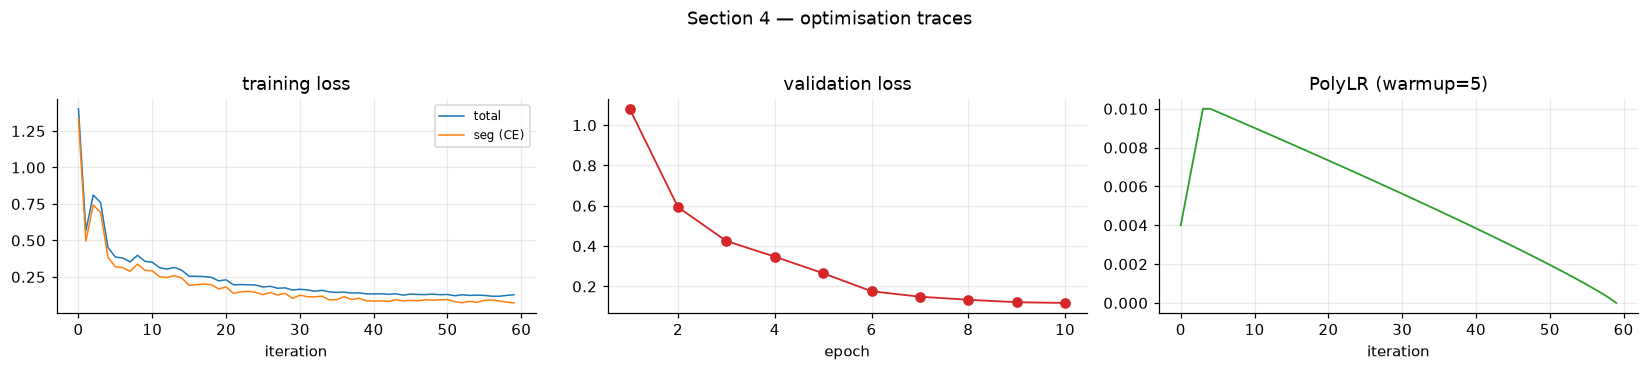

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
axes[0].plot(history["loss"], lw=1, label="total")
axes[0].plot(history["seg"],  lw=1, label="seg (CE)")
axes[0].set_xlabel("iteration"); axes[0].set_title("training loss"); axes[0].legend(fontsize=8)

axes[1].plot(np.arange(1, len(val_curve) + 1), val_curve, "o-", lw=1.2, color="tab:red")
axes[1].set_xlabel("epoch"); axes[1].set_title("validation loss")

axes[2].plot(history["lr"], lw=1.2, color="tab:green")
axes[2].set_xlabel("iteration"); axes[2].set_title(f"PolyLR (warmup={exp_cfg['lr_scheduler']['warmup']})")
fig.suptitle("Section 4 — optimisation traces", y=1.04)
plt.tight_layout(); plt.show()

## 5. Checkpoint

Saved in `train.py`'s exact layout. The test scripts load `<exp_name>_best.pth`,
which `train.py` produces by copying the latest checkpoint whenever validation
loss improves.

In [26]:
save_dict = {"epoch": MAX_EPOCHES - 1,
             "net": net.state_dict(),
             "optim": optimizer.state_dict(),
             "lr_scheduler": lr_scheduler.state_dict(),
             "best_val_loss": best_val_loss}

ckpt = EXP_DIR / f"{EXP_NAME}.pth"
torch.save(save_dict, ckpt)
shutil.copyfile(ckpt, EXP_DIR / f"{EXP_NAME}_best.pth")
print(f"{ckpt.name} ({ckpt.stat().st_size/1e6:.0f} MB) + {EXP_NAME}_best.pth")

exp_notebook.pth (164 MB) + exp_notebook_best.pth


## 6. Validation predictions

`train.py:val()` pushes overlays to TensorBoard every 5th batch. Same
visualisation, drawn inline: a lane channel is painted only where its existence
logit clears 0.5, exactly as the original does.

In [27]:
val_sample = next(iter(val_loader))
net.eval()
with torch.no_grad():
    seg_p, exist_p = net(val_sample["img"].to(device))[:2]
    seg_p   = torch.softmax(seg_p, dim=1).cpu().numpy()
    exist_p = exist_p.cpu().numpy()

In [28]:
def predicted_mask(seg, exist, thresh=.5):
    """argmax map, zeroed for lanes the existence head rejects."""
    mask = np.argmax(seg, axis=0)
    for i in range(4):
        if exist[i] <= thresh:
            mask[mask == i + 1] = 0
    return mask

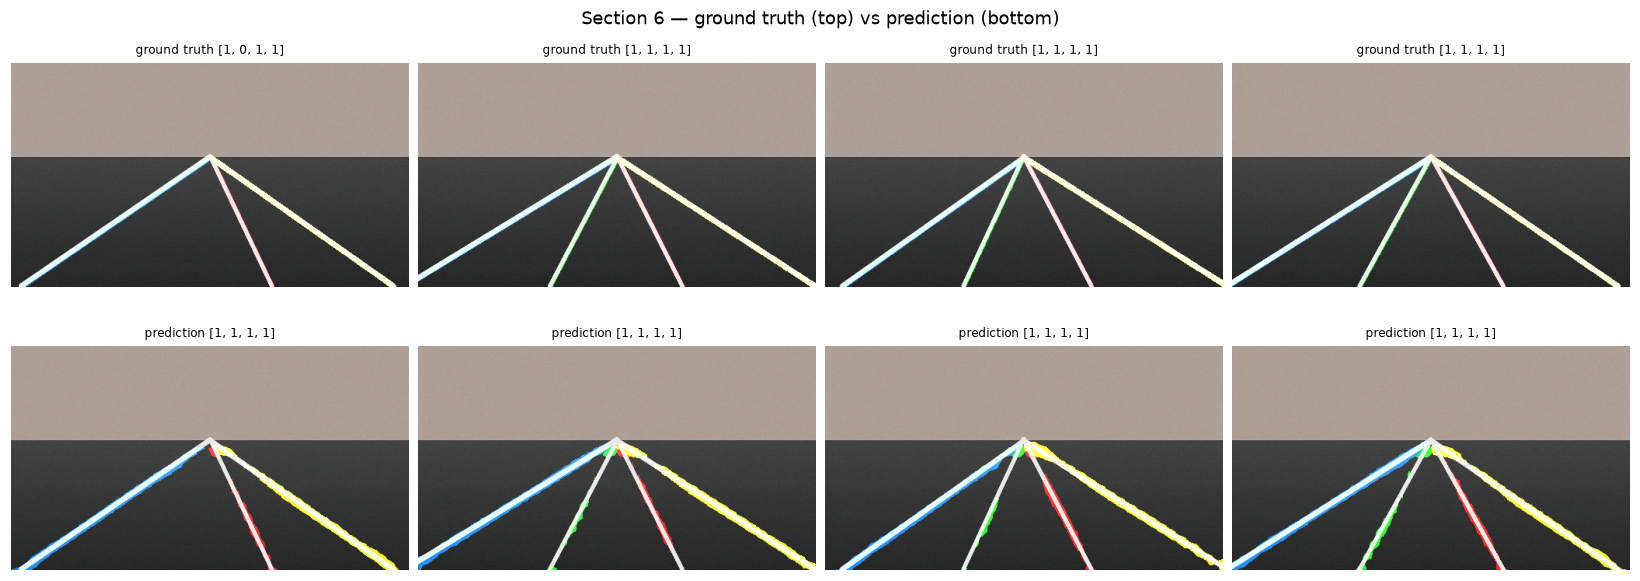

In [29]:
n = min(4, len(val_sample["img"]))
fig, axes = plt.subplots(2, n, figsize=(3.7 * n, 5.4), squeeze=False, layout="constrained")
for j in range(n):
    rgb = denorm(val_sample["img"][j])
    axes[0][j].imshow(overlay(rgb, val_sample["segLabel"][j].numpy()))
    axes[0][j].set_title(f"ground truth {val_sample['exist'][j].int().tolist()}", fontsize=8)
    axes[1][j].imshow(overlay(rgb, predicted_mask(seg_p[j], exist_p[j])))
    axes[1][j].set_title(f"prediction {(exist_p[j] > .5).astype(int).tolist()}", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Section 6 — ground truth (top) vs prediction (bottom)")
plt.show()

## 7. Testing — segmentation to lane coordinates

`test_CULane.py` reloads `<exp>_best.pth`, runs the test split, converts each
probability map to discrete lane points with `utils/prob2lines/getLane.py`, and
writes one `.lines.txt` per frame under `coord_output/`, mirroring the input
directory tree. Coordinates are emitted at the **original** resolution
(590×1640 for CULane), not at `resize_shape` — the evaluator works in native
pixels.

In [30]:
from utils.prob2lines import getLane

eval_net = SCNN(input_size=resize_shape, pretrained=False)
sd = torch.load(EXP_DIR / f"{EXP_NAME}_best.pth", map_location="cpu", weights_only=False)
eval_net.load_state_dict(sd["net"])
eval_net = eval_net.to(device).eval()
print("loaded from epoch", sd["epoch"])

loaded from epoch 9


In [31]:
def split_path(path):
    """Verbatim from test_CULane.py — split a path into its components."""
    folders = []
    while True:
        path, folder = os.path.split(path)
        if folder != "":
            folders.insert(0, folder)
        else:
            if path != "":
                folders.insert(0, path)
            break
    return folders

In [32]:
out_path = EXP_DIR / "coord_output"; out_path.mkdir(exist_ok=True)
(EXP_DIR / "evaluate").mkdir(exist_ok=True)
NATIVE = (CU_H, CU_W) if USE_TOY else (590, 1640)   # (H, W) of the source frames
written, preview = 0, None

In [33]:
with torch.no_grad():
    for batch in test_loader:
        seg_b, exist_b = eval_net(batch["img"].to(device))[:2]
        seg_b   = torch.softmax(seg_b, dim=1).cpu().numpy()
        exist_b = exist_b.cpu().numpy()

        for b in range(len(seg_b)):
            exist = [int(exist_b[b, i] > .5) for i in range(4)]
            lanes = getLane.prob2lines_CULane(seg_b[b], exist, resize_shape=NATIVE,
                                              y_px_gap=20, pts=18)
            tree = split_path(batch["img_name"][b])
            dst  = out_path.joinpath(*tree[-3:-1]) / (tree[-1][:-3] + "lines.txt")
            dst.parent.mkdir(parents=True, exist_ok=True)
            dst.write_text("".join(" ".join(f"{x} {y}" for x, y in l) + " \n" for l in lanes))
            written += 1
            if preview is None and lanes:
                preview = (batch["img_name"][b], lanes, dst)
print(f"{written} .lines.txt files under {out_path.relative_to(REPO)}")

8 .lines.txt files under experiments/exp_notebook/coord_output


In [34]:
name, lanes, dst = preview
print(dst.relative_to(REPO), f"— {len(lanes)} lanes\n")
print("\n".join(dst.read_text().splitlines()[:2])[:300], "...")

experiments/exp_notebook/coord_output/driver_toy/test_clip/00000.lines.txt — 3 lanes

35.0 589 76.0 569 115.0 549 160.0 529 211.0 509 253.0 489 301.0 469 349.0 449 397.0 429 438.0 409 486.0 389 534.0 369 586.0 349 634.0 329 682.0 309 727.0 289 765.0 269 
1127.0 589 1108.0 569 1092.0 549 1076.0 529 1057.0 509 1041.0 489 1025.0 469 1002.0 449 986.0 429 967.0 409 948.0 389 932.0 369 919 ...


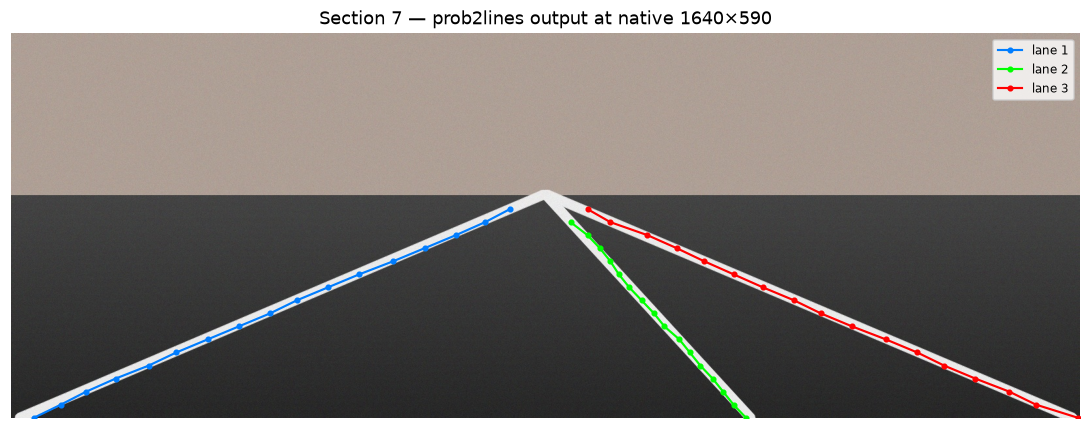

In [35]:
raw = cv2.cvtColor(cv2.imread(name), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(11, 4))
plt.imshow(raw)
for i, lane in enumerate(lanes):
    pts = np.array(lane)
    plt.plot(pts[:, 0], pts[:, 1], "o-", ms=3, lw=1.4,
             color=LANE_COLORS[i % 4] / 255, label=f"lane {i+1}")
plt.legend(fontsize=8, loc="upper right"); plt.axis("off")
plt.title(f"Section 7 — prob2lines output at native {NATIVE[1]}×{NATIVE[0]}")
plt.tight_layout(); plt.show()

## 8. Single-image demo with the published model

The model trained in section 4 predicts **pure background** on a real road
photo — it only ever saw synthetic triangles on a uniform road, so none of its
lane logits ever win the argmax. That is a data problem, not a pipeline one, and
the cell at the end of this section demonstrates it directly.

To actually replicate `demo_test.py` we need the published weights. Three
checkpoints are linked from the README:

| Checkpoint | Dataset | `resize_shape` | Source |
|---|---|---|---|
| `vgg_SCNN_DULR_w9.pth` | CULane | 800×288 | official lua-torch model, converted |
| `exp10_best.pth` | CULane | 800×288 | trained by the repo author |
| `exp0_best.pth` | Tusimple | 512×288 | trained by the repo author |

In [36]:
PUBLISHED = {   # README Google-Drive ids -> destination
    "vgg_SCNN_DULR_w9": ("1bBdN3yhoOQBC9pRtBUxzeRrKJdF7uVTJ",
                         REPO / "experiments/vgg_SCNN_DULR_w9/vgg_SCNN_DULR_w9.pth"),
    "exp10":            ("1AZn23w8RbMh1P6lJcVcf6PcTIWJvQg9u",
                         REPO / "experiments/exp10/exp10_best.pth"),
    "exp0":             ("1IwEenTekMt-t6Yr5WJU9_kv4d_Pegd_Q",
                         REPO / "experiments/exp0/exp0_best.pth"),
}

In [37]:
def fetch_published(name):
    """Download a README checkpoint on first use; no-op once it is on disk."""
    file_id, dst = PUBLISHED[name]
    if dst.exists():
        return dst
    import gdown                                   # pip install gdown
    dst.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id=file_id, output=str(dst), quiet=False)
    return dst

In [38]:
DEMO_CKPT = "vgg_SCNN_DULR_w9"                     # the model demo_test.py defaults to
ckpt_path = fetch_published(DEMO_CKPT)
demo_cfg  = json.loads((ckpt_path.parent / "cfg.json").read_text())
demo_shape = tuple(demo_cfg["dataset"]["resize_shape"])
print(f"{ckpt_path.name}  ({ckpt_path.stat().st_size/1e6:.0f} MB)  resize_shape={demo_shape}")

vgg_SCNN_DULR_w9.pth  (83 MB)  resize_shape=(800, 288)


In [39]:
demo_net = SCNN(input_size=demo_shape, pretrained=False)
demo_sd  = torch.load(ckpt_path, map_location="cpu", weights_only=False)
demo_net.load_state_dict(demo_sd["net"])           # strict: no missing / unexpected keys
demo_net = demo_net.to(device).eval()
print("loaded, epoch", demo_sd["epoch"])

loaded, epoch 0


`demo_test.py` normalises with **CULane** mean/std, not the ImageNet statistics
used in section 2 — these published weights were trained with the former, so the
transform has to match the checkpoint.

In [40]:
CU_MEAN, CU_STD = (0.3598, 0.3653, 0.3662), (0.2573, 0.2663, 0.2756)

demo_path = REPO / "demo" / "demo.jpg"
demo_full = cv2.cvtColor(cv2.imread(str(demo_path)), cv2.COLOR_BGR2RGB)
demo_rgb  = Resize(demo_shape)({"img": demo_full})["img"]
x = Compose(ToTensor(), Normalize(CU_MEAN, CU_STD))({"img": demo_rgb})["img"].unsqueeze(0)
print(f"{demo_path.name}  {demo_full.shape[1]}x{demo_full.shape[0]} -> {tuple(x.shape)}")

demo.jpg  1640x590 -> (1, 3, 288, 800)


In [41]:
with torch.no_grad():
    seg_d, exist_d = demo_net(x.to(device))[:2]
    seg_d   = torch.softmax(seg_d, dim=1)[0].cpu().numpy()
    exist_d = exist_d[0].cpu().numpy()

counts = {i: int((seg_d.argmax(0) == i).sum()) for i in range(5)}
print("existence :", exist_d.round(3), "->", (exist_d > .5).astype(int).tolist())
print("argmax px :", counts)

existence : [0.012 0.995 0.997 0.997] -> [0, 1, 1, 1]
argmax px : {0: 221384, 1: 0, 2: 2913, 3: 2315, 4: 3788}


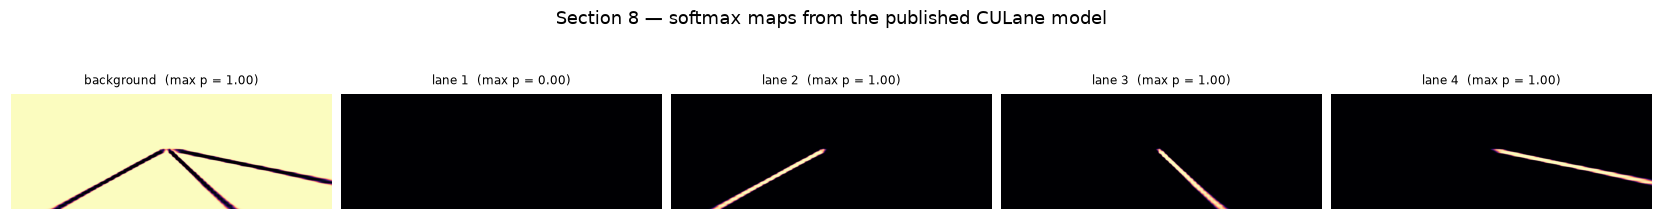

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(15, 2.4), layout="constrained")
for i, ax in enumerate(axes):
    ax.imshow(seg_d[i], cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"{NAMES[i]}  (max p = {seg_d[i].max():.2f})", fontsize=8)
    ax.axis("off")
fig.suptitle("Section 8 — softmax maps from the published CULane model")
plt.show()

### 8a. Overlay, against the reference output committed to the repo

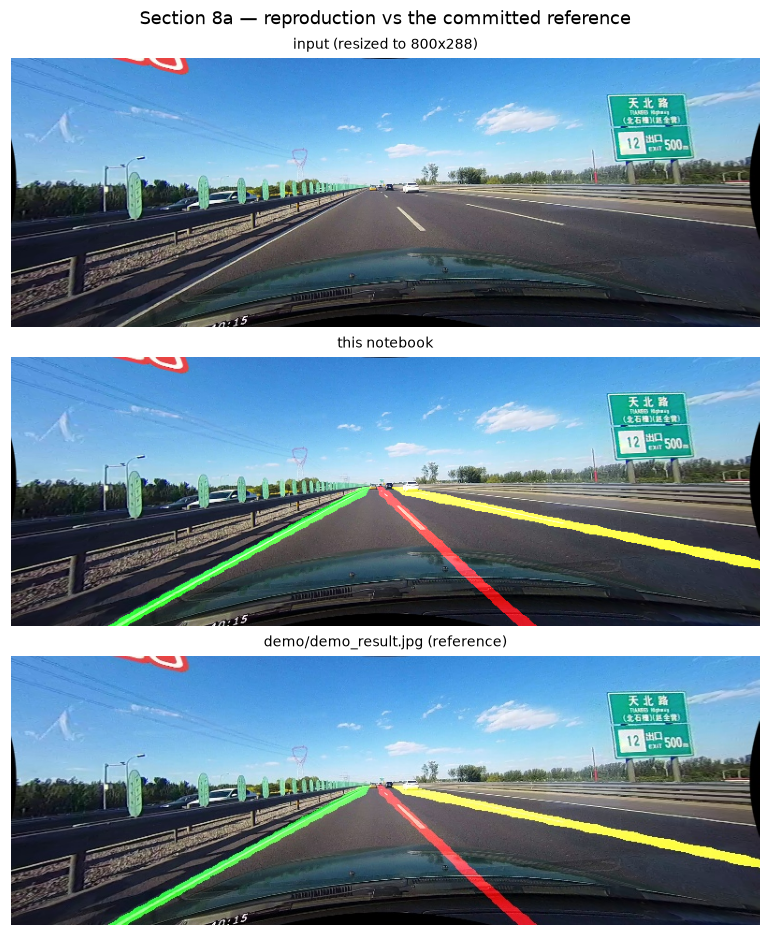

In [43]:
pred_overlay = overlay(demo_rgb, predicted_mask(seg_d, exist_d))
reference    = cv2.cvtColor(cv2.imread(str(REPO / "demo" / "demo_result.jpg")), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(3, 1, figsize=(11, 8.4), layout="constrained")
for ax, im, t in zip(axes, [demo_rgb, pred_overlay, reference],
                     ["input (resized to 800x288)", "this notebook", "demo/demo_result.jpg (reference)"]):
    ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis("off")
fig.suptitle("Section 8a — reproduction vs the committed reference")
plt.show()

### 8b. Lane coordinates

Same `prob2lines_CULane` call the test script makes, at CULane's native
590×1640. These are the numbers `demo_test.py` prints and that the C++ evaluator
would score.

In [44]:
demo_exist  = [int(exist_d[i] > .5) for i in range(4)]
demo_lanes  = getLane.prob2lines_CULane(seg_d, demo_exist, resize_shape=(590, 1640),
                                        y_px_gap=20, pts=18)
print(f"{len(demo_lanes)} lanes detected")
for i, l in enumerate(demo_lanes):
    print(f"  lane {i+1}: {len(l)} points, x {l[0][0]:.0f}->{l[-1][0]:.0f}, y {l[0][1]}->{l[-1][1]}")

3 lanes detected
  lane 1: 16 points, x 239->770, y 589->289
  lane 2: 16 points, x 1127->811, y 589->289
  lane 3: 9 points, x 1596->863, y 449->289


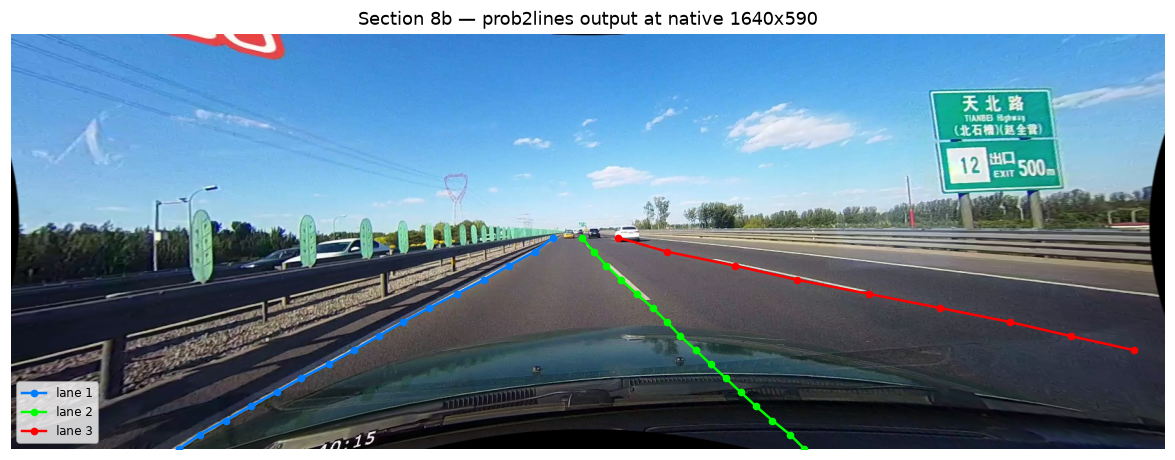

In [45]:
plt.figure(figsize=(11, 4.2))
plt.imshow(cv2.resize(demo_full, (1640, 590)))
for i, lane in enumerate(demo_lanes):
    pts = np.array(lane)
    plt.plot(pts[:, 0], pts[:, 1], "o-", ms=4, lw=1.6,
             color=LANE_COLORS[i % 4] / 255, label=f"lane {i+1}")
plt.legend(fontsize=8, loc="lower left"); plt.axis("off")
plt.title("Section 8b — prob2lines output at native 1640x590")
plt.tight_layout(); plt.show()

### 8c. Why the section-4 model produced nothing

Same image, same code path, the toy-trained checkpoint instead. The existence
head still fires on all four lanes — it is the segmentation branch that has
collapsed, so there are no lane pixels left to paint.

In [46]:
toy_rgb = Resize(resize_shape)({"img": demo_full})["img"]
toy_x   = Compose(ToTensor(), Normalize(mean, std))({"img": toy_rgb})["img"].unsqueeze(0)
with torch.no_grad():
    s_t, e_t = eval_net(toy_x.to(device))[:2]
    s_t = torch.softmax(s_t, dim=1)[0].cpu().numpy(); e_t = e_t[0].cpu().numpy()

print("toy-trained  existence:", e_t.round(3))
print("toy-trained  argmax px:", {i: int((s_t.argmax(0) == i).sum()) for i in range(5)})
print("toy-trained  max lane p:", s_t[1:].max().round(3), " <- never beats background")

toy-trained  existence: [0.74  0.8   0.797 0.782]
toy-trained  argmax px: {0: 147456, 1: 0, 2: 0, 3: 0, 4: 0}
toy-trained  max lane p: 0.074  <- never beats background


## 9. Evaluation

Scoring is deliberately **out of process** in this repo. The network's job ends
at `coord_output/`; a separate evaluator reads those text files:

- **CULane** — `os.system("sh utils/lane_evaluation/CULane/Run.sh <exp_name>")`,
  a C++ binary that must be built first (`cmake .. && make`, needs OpenCV) and
  whose `Run.sh` has `root` and `data_dir` hardcoded as absolute paths. It
  scores nine test splits by curve IoU at `w_lane=30`.
- **Tusimple** — `LaneEval.bench_one_submit` in
  `utils/lane_evaluation/tusimple/lane.py`, pure Python over a
  `predict_test.json` dump.

Neither runs against toy data, so the cell below computes a plain pixel-level
IoU and existence accuracy on the validation split — enough to confirm the
segmentation head is learning, not a substitute for the official metrics.

In [47]:
@torch.no_grad()
def pixel_metrics():
    inter = np.zeros(4); union = np.zeros(4); correct = total = 0
    net.eval()
    for s in val_loader:
        seg, ex = net(s["img"].to(device))[:2]
        pred = seg.argmax(1).cpu().numpy()
        gt   = s["segLabel"].numpy()
        for i in range(4):
            p, g = pred == i + 1, gt == i + 1
            inter[i] += (p & g).sum(); union[i] += (p | g).sum()
        correct += ((ex.cpu().numpy() > .5) == (s["exist"].numpy() > .5)).sum()
        total   += s["exist"].numel()
    return inter / np.maximum(union, 1), correct / total

In [48]:
iou, exist_acc = pixel_metrics()
print("per-lane IoU :", iou.round(3))
print("mean IoU     :", iou.mean().round(3))
print("exist acc    :", round(float(exist_acc), 3))

per-lane IoU : [0.67  0.443 0.513 0.643]
mean IoU     : 0.567
exist acc    : 0.938


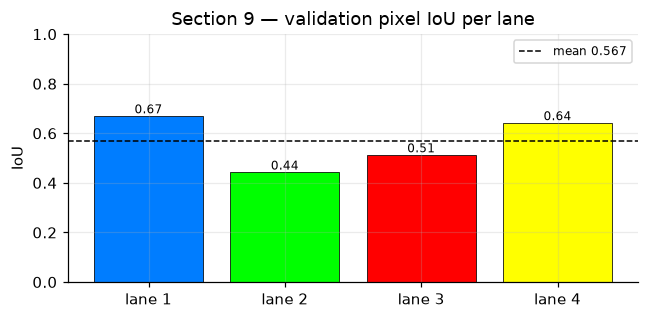

In [49]:
plt.figure(figsize=(6, 3))
bars = plt.bar([f"lane {i+1}" for i in range(4)], iou, color=LANE_COLORS / 255, edgecolor="k", lw=.5)
plt.axhline(iou.mean(), ls="--", lw=1, color="k", label=f"mean {iou.mean():.3f}")
for b, v in zip(bars, iou):
    plt.text(b.get_x() + b.get_width() / 2, v + .01, f"{v:.2f}", ha="center", fontsize=8)
plt.ylim(0, max(1., iou.max() * 1.2)); plt.ylabel("IoU"); plt.legend(fontsize=8)
plt.title("Section 9 — validation pixel IoU per lane")
plt.tight_layout(); plt.show()

## Running against the real datasets

1. Point `config.py`'s `Dataset_Path` at your CULane / Tusimple copy —
   `USE_TOY` in section 2 then flips to `False` and every cell below it works
   unchanged.
2. For CULane scoring, build the evaluator and fix its hardcoded paths:
   ```bash
   cd utils/lane_evaluation/CULane && mkdir build && cd build && cmake .. && make
   # then edit `root` and `data_dir` at the top of Run.sh
   ```
3. Raise `lr_scheduler.max_iter` in section 1 (the reference runs use 1500 for
   Tusimple, 8000 for CULane) and `batch_size` to what your GPU allows.
4. `train.py` hardcodes `torch.nn.DataParallel` and `num_workers=8`; this
   notebook drops both since it targets a single local device.